In [1]:
import pyabf
import numpy as np
import pandas as pd
from scipy.signal import find_peaks

In [2]:
laser_ma = {8: 500, 9: 700, 10: 900, 11: 1000, 12: 1100, 13: 1200, 14: 1400}
archivos = [8, 9, 10, 11, 12, 13, 14]
fases    = ["control", "laser", "rec"]
colores  = {"control": "#1a6fad", "laser": "#c0392b", "rec": "#2e7d32"}

ruta_base = r"C:\Users\Usuario\Documents\TFG\Experimento ABRIL 2026\27042026 patch"
ruta_analisis = r"C:\Users\Usuario\Documents\TFG\Experimento ABRIL 2026\ANÁLISIS"

FASE_DURACION = 150

archivos_info = {
    8:  {"control": (0, 163.1), "laser": (163.1, 314.8), "rec": (314.8, 480.0)},
    9:  {"control": (0, 154.3), "laser": (154.3, 310.3), "rec": (310.3, 480.0)},
    10: {"control": (0, 155.6), "laser": (155.6, 311.4), "rec": (311.4, 480.0)},
    11: {"control": (0, 152.1), "laser": (152.1, 304.9), "rec": (304.9, 480.0)},
    12: {"control": (0, 156.4), "laser": (156.4, 314.4), "rec": (314.4, 480.0)},
    13: {"control": (0, 153.7), "laser": (153.7, 314.3), "rec": (314.3, 480.0)},
    14: {"control": (0, 152.9), "laser": (152.9, 307.8), "rec": (307.8, 480.0)},
}

## Cálculo de pendientes de despolarización y repolarización

La derivada dV/dt se calcula con np.diff en mV/ms.
El reposo local de cada AP se estima como la media del voltaje en la ventana [-8ms, -5ms] antes del pico,
justo antes de que comience la despolarización.
A partir de ese reposo calculamos la semiamplitud y buscamos el cruce hacia arriba (despolarización)
y hacia abajo (repolarización) para obtener la pendiente en ese punto exacto.
Las ventanas son asimétricas: 10ms antes del pico para la despolarización y 3ms después para la repolarización.

In [4]:
resultados_pendientes = []

for num in archivos:
    abf = pyabf.ABF(rf"{ruta_base}\264270{num:02d}.abf")
    abf.setSweep(0, channel=0)
    tiempo = abf.sweepX
    vm = abf.sweepY
    fs = abf.dataRate

    w_antes = int(10 * fs / 1000)
    w_des= int(3* fs / 1000)

    for fase in fases:
        t0= archivos_info[num][fase][0]
        mask= (tiempo >= t0) & (tiempo <= t0 + FASE_DURACION)
        vm_fase = vm[mask]
        dvm = np.diff(vm_fase) * fs / 1000

        picos, _ = find_peaks(vm_fase, height=0, distance=int(0.05 * fs))

        for p in picos:
            if p - w_antes - int(5 * fs / 1000) < 0 or p + w_des >= len(dvm):
                continue
            v_pico = vm_fase[p]

            inicio_reposo  = p - w_antes - int(5 * fs / 1000)
            fin_reposo = p - w_antes
            v_reposo_local = np.mean(vm_fase[inicio_reposo:fin_reposo])
            v_medio = v_reposo_local + (v_pico - v_reposo_local)/2      # Fórmula para Vmedio!!

            seg_subida = vm_fase[p - w_antes:p]
            cruces_sub = np.where((seg_subida[:-1] < v_medio) & (seg_subida[1:] >= v_medio))[0]
            idx_despo = (p - w_antes) + cruces_sub[-1]
            slope_despo = dvm[idx_despo]

            seg_bajada = vm_fase[p:p + w_des]
            cruces_baj = np.where((seg_bajada[:-1] >= v_medio) & (seg_bajada[1:] < v_medio))[0]
            idx_repo = p + cruces_baj[0]
            slope_repo = dvm[idx_repo]

            resultados_pendientes.append({
                "archivo": num,
                "intensidad": laser_ma[num],
                "fase": fase,
                "slope_despo": slope_despo,
                "slope_repo": slope_repo,
            })

df_pend = pd.DataFrame(resultados_pendientes)
df_pend.groupby(["archivo", "intensidad", "fase"])[["slope_despo", "slope_repo"]].agg(["mean","std"]).round(2)

slope_despo            slope_repo      
                                  mean        std       mean   std
archivo intensidad fase                                           
8       500        control  113.809998  12.300000 -38.810001  3.49
                   laser    124.639999  25.750000 -49.660000  8.18
                   rec      163.509995  19.389999 -48.740002  5.11
9       700        control  176.380005  13.400000 -52.080002  3.12
                   laser    157.110001  13.560000 -67.320000  2.51
                   rec      150.669998  17.629999 -46.599998  4.77
10      900        control  136.139999  15.060000 -44.669998  4.25
                   laser    136.850006   8.380000 -66.150002  2.88
                   rec      122.919998  14.690000 -44.610001  4.35
11      1000       control  118.449997  13.730000 -43.230000  3.89
                   laser    126.080002   5.040000 -65.110001  3.12
                   rec      116.620003  11.480000 -44.389999  3.97
12      1100       control  108.320000  10.610000 -41.410000  2.88
                   laser    114.309998   6.890000 -64.360001  3.94
                   rec      113.760002  12.030000 -44.549999  3.95
13      1200       control  109.800003  12.860000 -43.330002  3.56
                   laser    112.730003   9.950000 -69.580002  2.56
                   rec      116.480003  14.370000 -48.610001  4.32
14      1400       control  124.400002  15.610000 -50.340000  4.47
                   rec      125.980003  18.430000 -52.580002  4.74

# FIGURA

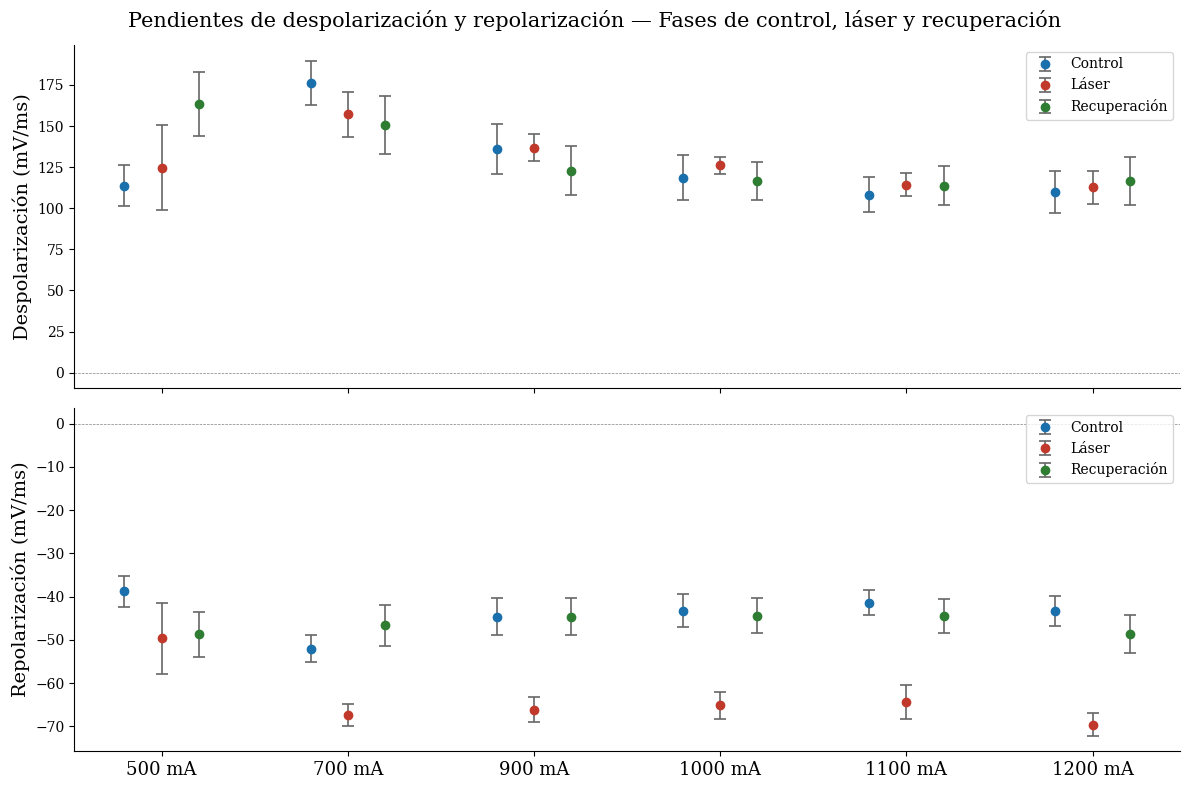

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'cm'

archivos_plot = [8, 9, 10, 11, 12, 13]
offsets = {"control": -0.2, "laser": 0.0, "rec": 0.2}
labels= {"control": "Control", "laser": "Láser", "rec": "Recuperación"}

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for ax, metrica, ylabel in zip(axes, ["slope_despo", "slope_repo"],
                                     ["Despolarización (mV/ms)", "Repolarización (mV/ms)"]):
    for fase in fases:
        medias, stds = [], []
        for n in archivos_plot:
            sub = df_pend[(df_pend.archivo == n) & (df_pend.fase == fase)]
            medias.append(sub[metrica].mean())
            stds.append(sub[metrica].std())

        xpos = np.arange(len(archivos_plot)) + offsets[fase]
        ax.errorbar(xpos, medias, yerr=stds, fmt='o', color=colores[fase],
                    label=labels[fase], markersize=6, capsize=4, capthick=1.2,
                    elinewidth=1.2, ecolor='#666666', linewidth=0)

    ax.set_ylabel(ylabel, fontsize=14)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.legend(fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[1].set_xticks(np.arange(len(archivos_plot)))
axes[1].set_xticklabels([f"{laser_ma[n]} mA" for n in archivos_plot], fontsize=13)

fig.suptitle("Pendientes de despolarización y repolarización — Fases de control, láser y recuperación", fontsize=15)
plt.tight_layout()
plt.show()